# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [28]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [29]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 577


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [5]:
# Set the API base URL
url = "http://api.openweathermap.org/data/2.5/weather?units=Metric&APPID=" + weather_api_key

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = url + "&q=" + city

    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        city_weather = requests.get(city_url).json()


        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        # Append the City information into city_data list
        city_data.append({"City": city,
                          "Lat": city_lat,
                          "Lng": city_lng,
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | nar'yan-mar
Processing Record 2 of Set 1 | crane
Processing Record 3 of Set 1 | manacapuru
Processing Record 4 of Set 1 | blackmans bay
Processing Record 5 of Set 1 | puerto natales
Processing Record 6 of Set 1 | castillos
Processing Record 7 of Set 1 | espargos
City not found. Skipping...
Processing Record 8 of Set 1 | mashava
Processing Record 9 of Set 1 | colonia
Processing Record 10 of Set 1 | lorengau
Processing Record 11 of Set 1 | adamstown
Processing Record 12 of Set 1 | yicheng
Processing Record 13 of Set 1 | vorgashor
Processing Record 14 of Set 1 | itamaraca
Processing Record 15 of Set 1 | codrington
Processing Record 16 of Set 1 | tazovsky
Processing Record 17 of Set 1 | nosivka
Processing Record 18 of Set 1 | buka
Processing Record 19 of Set 1 | invercargill
Processing Record 20 of Set 1 | kataragama
City not found. Skipping...
Processing Record 21 of Set 1 | bathurst
Processing Reco

In [6]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          573
Lat           573
Lng           573
Max Temp      573
Humidity      573
Cloudiness    573
Wind Speed    573
Country       573
Date          573
dtype: int64

In [7]:
# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,nar'yan-mar,67.6713,53.0870,-5.97,86,9,7.03,RU,1744183406
1,crane,31.3974,-102.3501,16.55,20,0,6.88,US,1744183407
2,manacapuru,-3.2997,-60.6206,24.01,95,100,1.07,BR,1744183408
3,blackmans bay,-43.0167,147.3167,16.96,64,0,2.40,AU,1744183409
4,puerto natales,-51.7236,-72.4875,7.48,87,100,0.79,CL,1744183410


In [8]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [9]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,nar'yan-mar,67.6713,53.0870,-5.97,86,9,7.03,RU,1744183406
1,crane,31.3974,-102.3501,16.55,20,0,6.88,US,1744183407
2,manacapuru,-3.2997,-60.6206,24.01,95,100,1.07,BR,1744183408
3,blackmans bay,-43.0167,147.3167,16.96,64,0,2.40,AU,1744183409
4,puerto natales,-51.7236,-72.4875,7.48,87,100,0.79,CL,1744183410


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

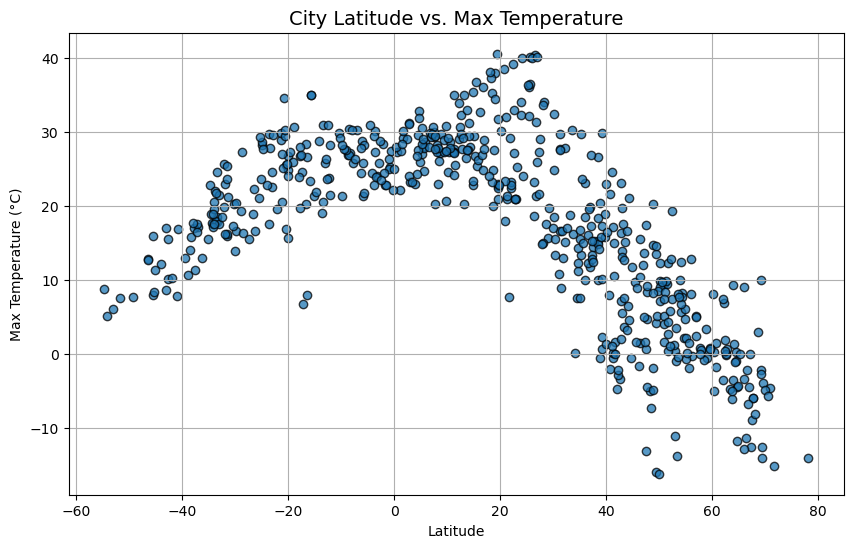

In [10]:
# Build scatter plot for latitude vs. temperature
plt.figure(figsize=(10,6))
plt.scatter(city_data_df["Lat"], city_data_df["Max Temp"], edgecolor='black', linewidths=1, alpha=0.75)

# Incorporate other graph properties
plt.title("City Latitude vs. Max Temperature", fontsize=14)
plt.xlabel("Latitude")
plt.ylabel("Max Temperature (°C)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

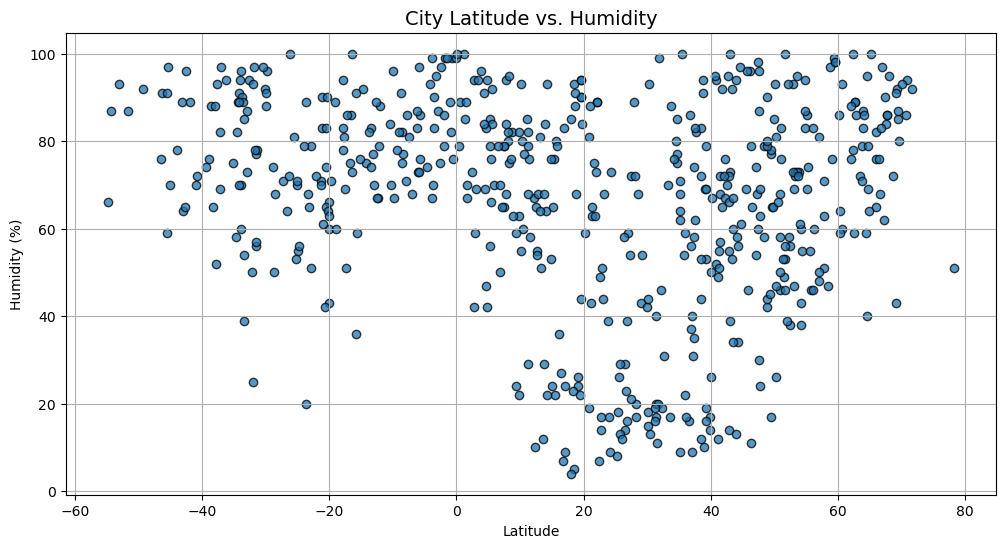

In [12]:
# Build the scatter plots for latitude vs. humidity
plt.figure(figsize=(12,6))
plt.scatter(city_data_df["Lat"], city_data_df["Humidity"], edgecolor='black', linewidths=1, alpha=0.75)

# Incorporate the other graph properties
plt.title("City Latitude vs. Humidity", fontsize=14)
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

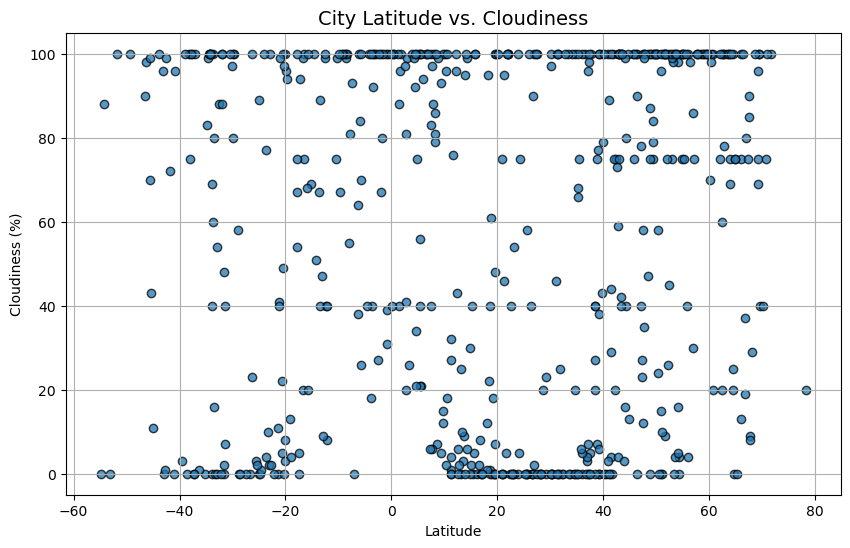

In [13]:
# Build the scatter plots for latitude vs. cloudiness
plt.figure(figsize=(10,6))
plt.scatter(city_data_df["Lat"], city_data_df["Cloudiness"], edgecolor='black', linewidths=1, alpha=0.75)

# Incorporate the other graph properties
plt.title("City Latitude vs. Cloudiness", fontsize=14)
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

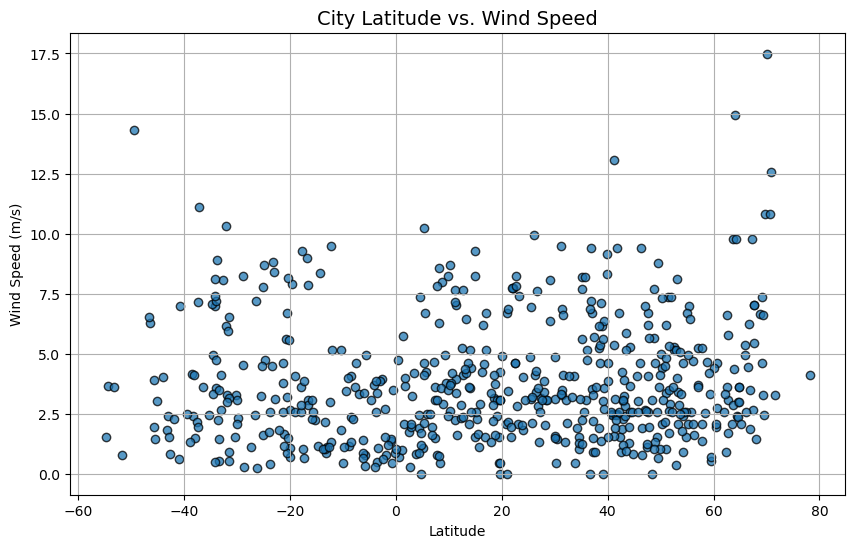

In [14]:
# Build the scatter plots for latitude vs. wind speed
plt.figure(figsize=(10,6))
plt.scatter(city_data_df["Lat"], city_data_df["Wind Speed"], edgecolor='black', linewidths=1, alpha=0.75)

# Incorporate the other graph properties
plt.title("City Latitude vs. Wind Speed", fontsize=14)
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [39]:
# Define a function to create Linear Regression plot
def linear_reg(x_values, y_values, title, text_coords):
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
    reg_values = x_values * slope + intercept
    lin_eq = "y = " + str(round(slope, 2)) + "x+" + str(round(intercept, 2))
    
    # Plot the regression
    plt.scatter(x_values, y_values, color="magenta", edgecolor="black", linewidth=1)
    plt.plot(x_values, reg_values, color="black",)
    plt.annotate(lin_eq, text_coords, color="black", fontsize=12)

    # Labels
    plt.xlabel("Latitude", fontfamily="Arial", fontsize=12)
    plt.ylabel(title, fontfamily="Arial", fontsize=12)
    plt.title(f"Latitide vs. {title}", fontfamily="Arial", fontsize=16)

    # Show the plot
    plt.show()

In [40]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df[city_data_df["Lat"] >= 0]

# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,nar'yan-mar,67.6713,53.0870,-5.97,86,9,7.03,RU,1744183406
1,crane,31.3974,-102.3501,16.55,20,0,6.88,US,1744183407
7,colonia,50.9333,6.9500,9.47,68,0,1.03,DE,1744183415
10,yicheng,31.3705,119.8703,27.63,40,100,3.26,CN,1744183418
11,vorgashor,67.5833,63.9500,-8.95,84,90,5.44,RU,1744183419


In [41]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df[city_data_df["Lat"] < 0]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
2,manacapuru,-3.2997,-60.6206,24.01,95,100,1.07,BR,1744183408
3,blackmans bay,-43.0167,147.3167,16.96,64,0,2.40,AU,1744183409
4,puerto natales,-51.7236,-72.4875,7.48,87,100,0.79,CL,1744183410
5,castillos,-34.1667,-53.8333,17.54,91,100,6.97,UY,1744183411
6,mashava,-20.0367,30.4823,26.71,43,3,2.67,ZW,1744183414


###  Temperature vs. Latitude Linear Regression Plot

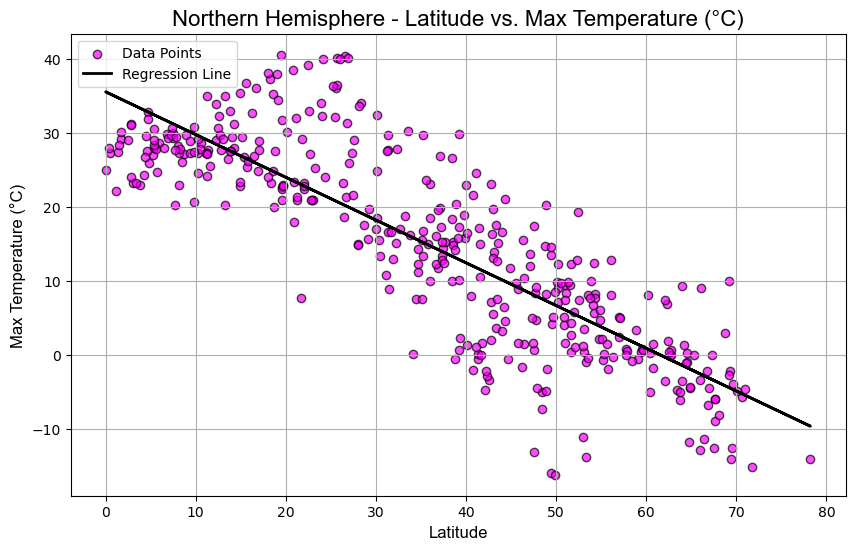

In [43]:
# Linear regression on Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Max Temp"]

# Plot Northern Hemisphere temperatures with a custom linear regression plot
linear_reg(x_values, y_values, "Latitude", "Max Temperature (°C)", 
           "Northern Hemisphere", (10, -30))

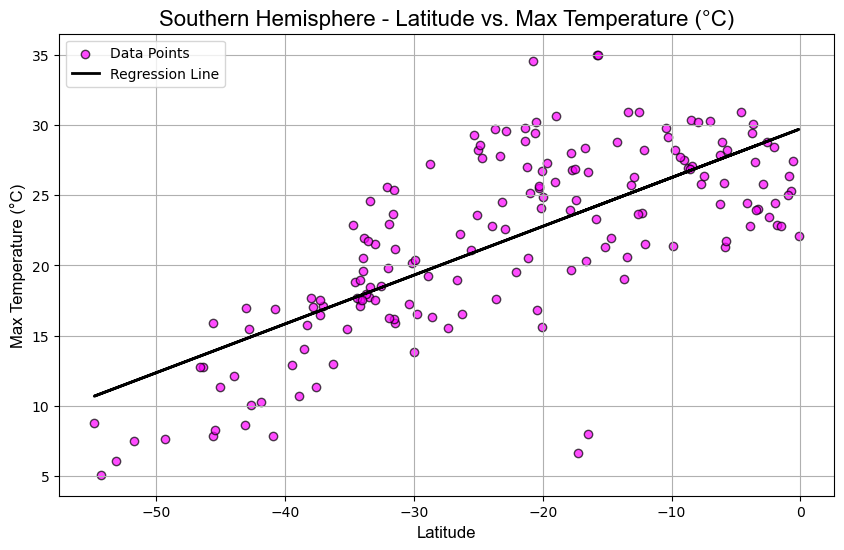

In [44]:
# Linear regression on Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Max Temp"]

# Plot Southern Hemisphere temperatures with a custom linear regression plot
linear_reg(x_values, y_values, "Latitude", "Max Temperature (°C)", 
           "Southern Hemisphere", (10, 30))

**Discussion about the linear relationship:** When examining the relationship between latitude and temperature across both hemispheres, it becomes apparent that the Northern Hemisphere exhibits a more pronounced correlation. This suggests that as one moves further northward from the equator, a clear and consistent decline in temperature is observed, reinforcing the expectation of cooler conditions at higher latitudes.


### Humidity vs. Latitude Linear Regression Plot

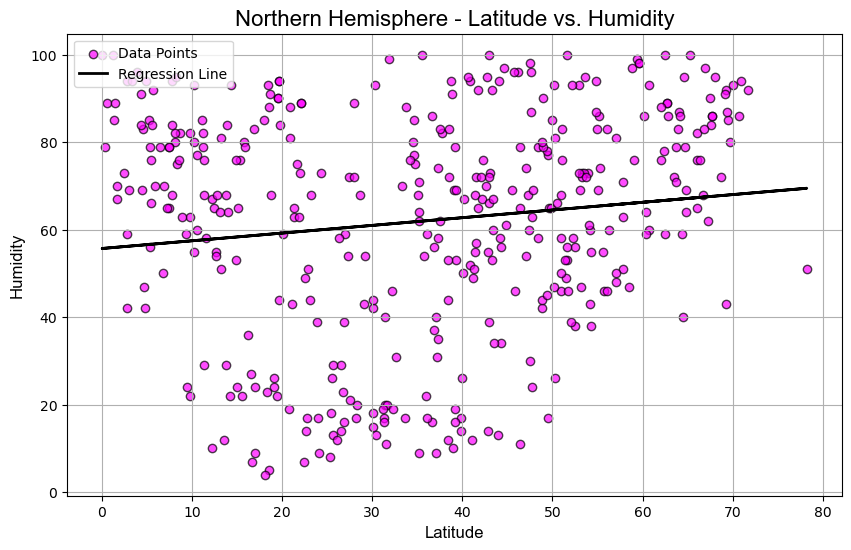

In [51]:
# Linear regression on Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Humidity"]

# Plot Northern Hemisphere temperatures with a custom linear regression plot
linear_reg(x_values, y_values, "Latitude", "Humidity", 
           "Northern Hemisphere", (10, -30))


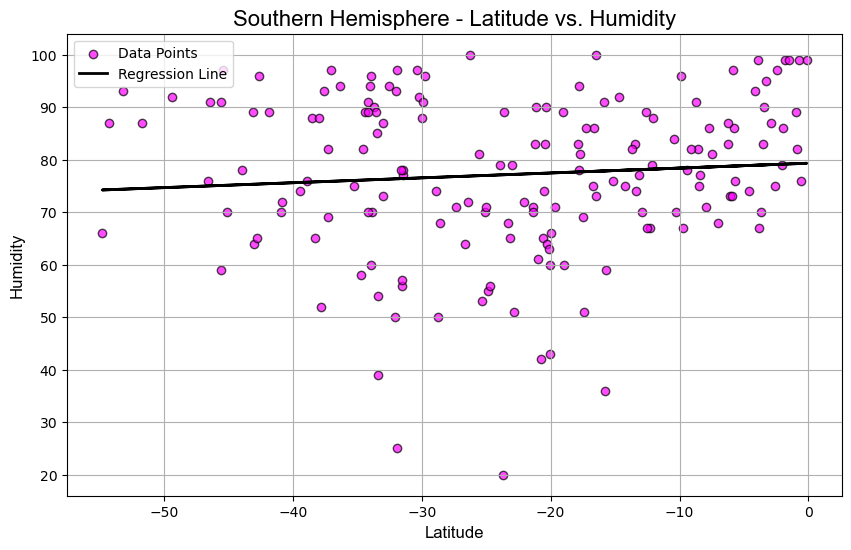

In [52]:
# Linear regression on Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Humidity"]

# Plot Southern Hemisphere temperatures with a custom linear regression plot
linear_reg(x_values, y_values, "Latitude", "Humidity", 
           "Southern Hemisphere", (10, 30))

**Discussion about the linear relationship:** the correlation between latitude and humidity in the Southern Hemisphere is weaker compared to the Northern Hemisphere. This disparity can largely be attributed to the differences in sample sizes between the two hemispheres, with the Southern Hemisphere being less represented in the dataset.

### Cloudiness vs. Latitude Linear Regression Plot

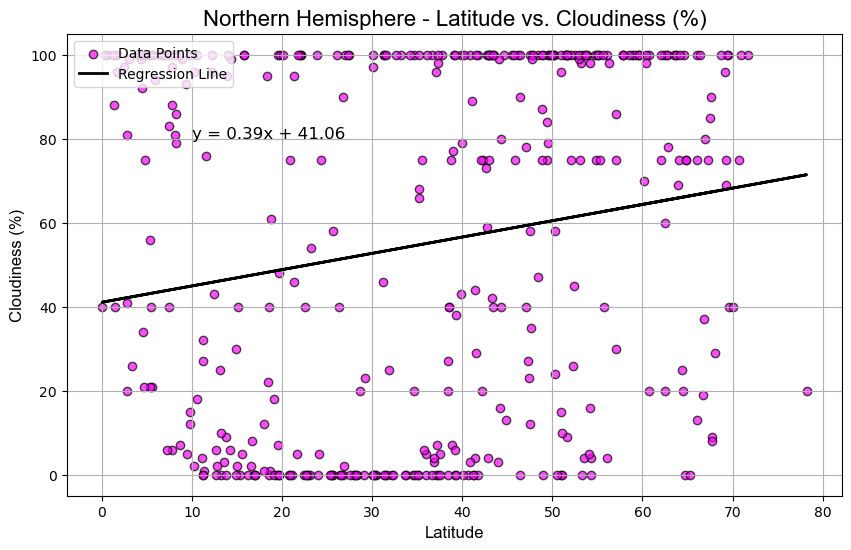

In [53]:
# Linear regression on Northern Hemisphere (Latitude vs Cloudiness)
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Cloudiness"]

# Plot Northern Hemisphere cloudiness with a custom linear regression plot
linear_reg(x_values, y_values, "Latitude", "Cloudiness (%)", 
           "Northern Hemisphere", (10, 80))


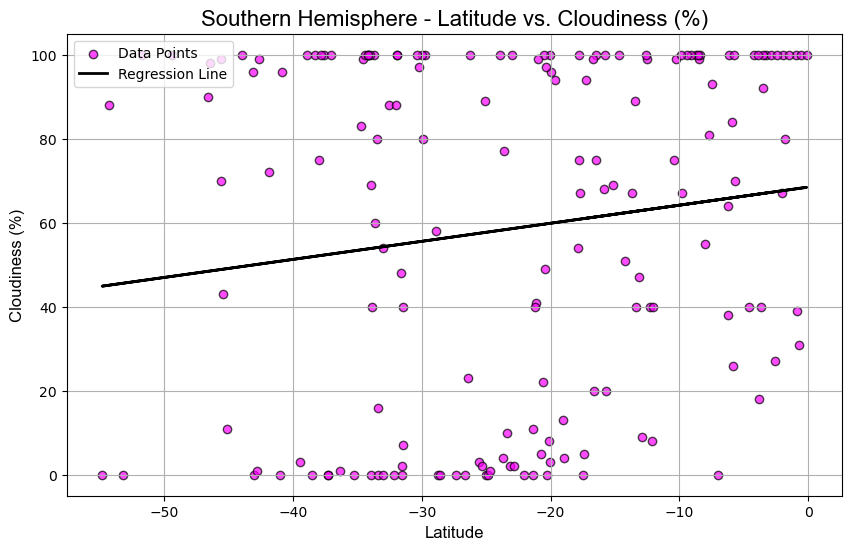

In [54]:
# Linear regression on Southern Hemisphere (Latitude vs Cloudiness)
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Cloudiness"]

# Plot Southern Hemisphere cloudiness with a custom linear regression plot
linear_reg(x_values, y_values, "Latitude", "Cloudiness (%)", 
           "Southern Hemisphere", (10, 80))


**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Wind Speed vs. Latitude Linear Regression Plot

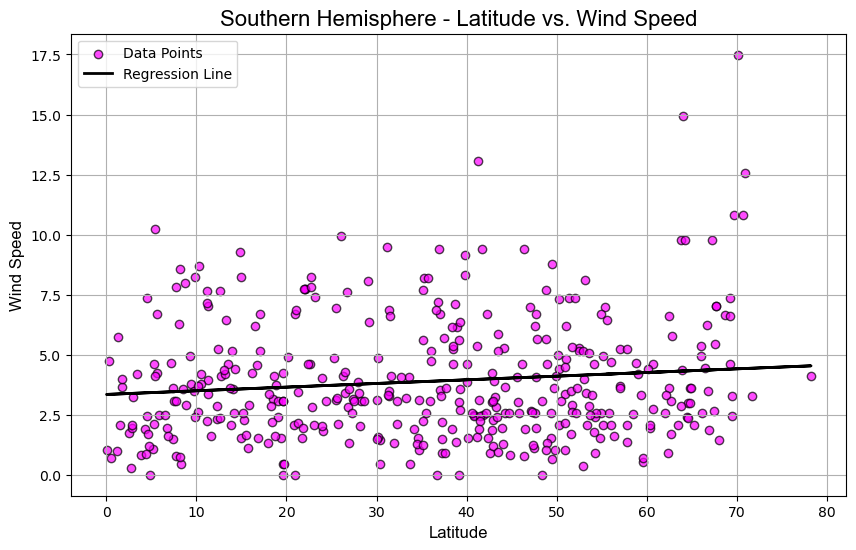

In [56]:

x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Wind Speed"]
linear_reg(x_values, y_values, "Latitude", "Wind Speed", 
           "Southern Hemisphere", (10, 80))


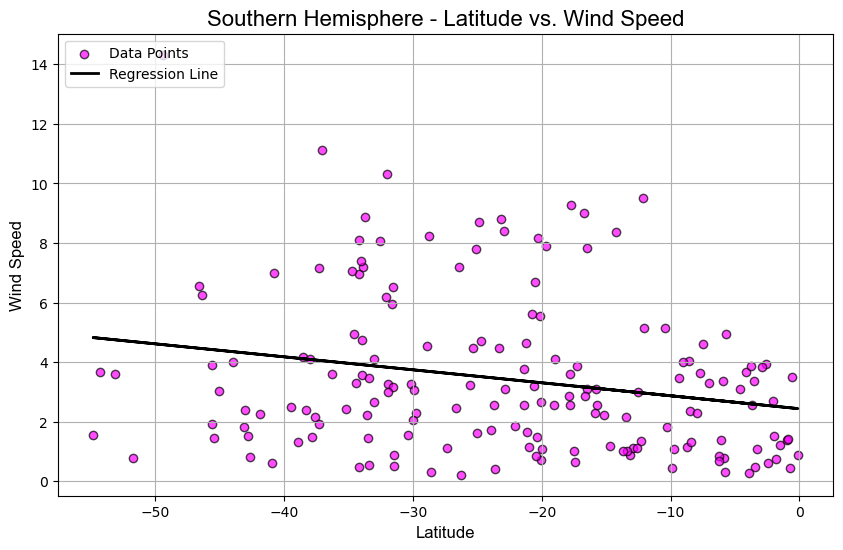

In [57]:
# Linear regression on Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Wind Speed"]
linear_reg(x_values, y_values, "Latitude", "Wind Speed", 
           "Southern Hemisphere", (10, 80))


**Discussion about the linear relationship:** YOUR RESPONSE HERE